### Testing custom TTF transformations
This notebook can be used to visualize the different (custom) versions of the TTF transformation.

In [1]:
# Standard modules
import os
import sys

import numpy as np
import openturns as ot

# ML modules
import torch

# visualization
import matplotlib.pyplot as plt

# To avoid meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# local modules
from tailnflows.models.extreme_transformations import TailAffineMarginalTransform
from tailnflows.models.tail_estimation import estimate_df

### Plot the 1d Transformation

In [20]:
def plot_transform(transform: TailAffineMarginalTransform, x_low: float = -5.0, x_high: float = 5.0, num_points: int = 1000):
    """
    Plot the forward and inverse transformations along with their lads.
    
    Args:
        transform (TailAffineMarginalTransform): The transformation to plot.
        x_low (float): The lower bound of the domain on which to plot.
        x_high (float): The upper bound of the domain on which to plot.
        num_points (int): The number of points to plot.
    """
    x = np.linspace(x_low, x_high, num_points)
    x_tensor = torch.from_numpy(x).to('cpu').float().unsqueeze(-1)
    y_fwd, lad_fwd = transform.forward(x_tensor)
    y_fwd = y_fwd.detach().numpy()
    lad_fwd = lad_fwd.detach().numpy()
    y_back, lad_back = transform.inverse(x_tensor)
    y_back = y_back.detach().numpy()
    lad_back = lad_back.detach().numpy()
    

    fig, axs = plt.subplots(2, 2, figsize=(12, 6))
    axs[0, 0].plot(x, y_fwd)
    axs[0, 0].set_title('Forward Transformation')
    axs[0, 0].grid()
    axs[0, 0].set_xlim(x_low, x_high)
    axs[0, 1].plot(x, lad_fwd)
    axs[0, 1].set_title('Forward Transformation Lad')
    axs[0, 1].grid()
    axs[0, 1].set_xlim(x_low, x_high)
    axs[1, 0].plot(x, y_back)
    axs[1, 0].set_title('Inverse Transformation')
    axs[1, 0].grid()
    axs[1, 0].set_xlim(x_low, x_high)
    axs[1, 1].plot(x, lad_back)
    axs[1, 1].set_title('Inverse Transformation Lad')
    axs[1, 1].grid()
    axs[1, 1].set_xlim(x_low, x_high)

    fig.show()

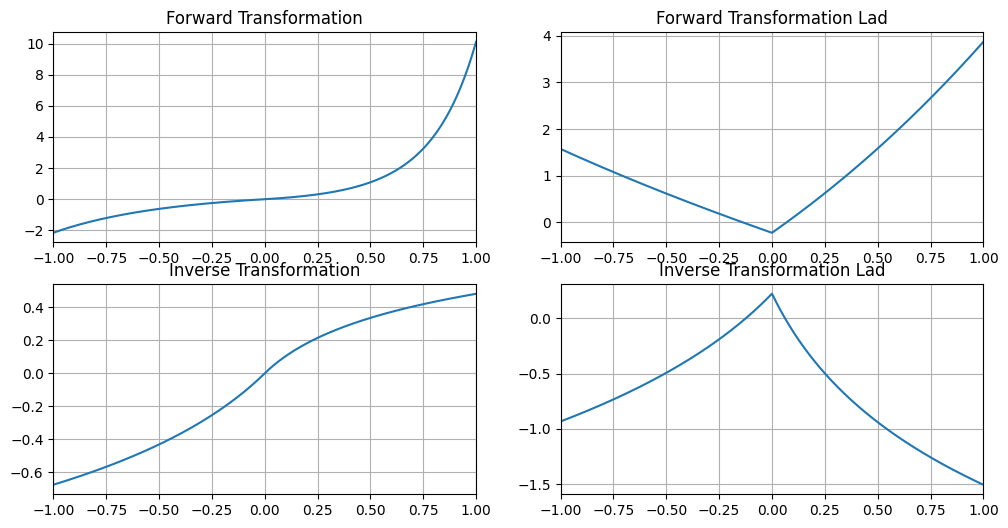

In [25]:
# Parameters for the transformation
features = 1
pos_tail = 3.0
neg_tail = 1.0
shift = 0.0
scale = 1.0
custom = None
a = None

transform = TailAffineMarginalTransform(features, torch.tensor([pos_tail]), torch.tensor([neg_tail]), torch.tensor([shift]), torch.tensor([scale]))

x_low = -1.0
x_high = 1.0

plot_transform(transform, x_low, x_high)